In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)
pd.options.display.float_format = '{:,.2f}'.format

from sklearn import preprocessing
from scipy.stats import chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
#import category_encoders as ce

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

In [2]:
product_target = 'fam_investment'
save_path = 'data/df_' + product_target + '.csv'
save_path

'data/df_fam_investment.csv'

In [3]:
df = pd.read_csv(save_path)
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [4]:
# Nos quedamos con los clientes vivos para luego descartar los muertos de la predicción:
df_non_deceased_last_partition = df[(df["pk_partition"]==df["pk_partition"].max())&(df["deceased"]=='N')].drop_duplicates()
df_non_deceased_last_partition

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,loans,mortgage,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y
16,1000028,2019-05-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,44,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,28.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
33,1000096,2019-05-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,10,N,0.00,0,0,0,0,0.00,0.00,0,0,0,0,0,53.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
56,1000113,2019-05-01,2015-04-01,KAT,0.00,02 - PARTICULARES,ES,14.00,V,54,N,"136,705.50",0,0,0,0,0.00,0.00,0,0,0,0,0,50.00,0.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
67,1000130,2019-05-01,2018-03-01,KAT,1.00,02 - PARTICULARES,ES,28.00,H,44,N,"126,133.50",0,0,0,0,0.00,0.00,0,0,0,0,0,14.00,0.27,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
84,1000157,2019-05-01,2016-03-01,KFC,1.00,02 - PARTICULARES,ES,46.00,V,44,N,"68,038.20",0,0,0,0,0.00,0.00,0,0,0,0,1,39.00,0.94,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5781641,998837,2019-05-01,2018-05-01,KAT,1.00,02 - PARTICULARES,ES,41.00,V,37,N,"113,316.87",0,0,0,0,0.00,0.00,0,0,0,0,1,12.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
5781658,998859,2019-05-01,2015-05-01,KFC,1.00,02 - PARTICULARES,ES,28.00,V,44,N,"126,242.40",0,0,0,1,1.00,1.00,1,1,1,0,0,49.00,1.00,0,02 - PARTICULARES,0,0,6.00,1,0.00,0.00
5781664,999706,2019-05-01,2018-12-01,KFC,0.00,02 - PARTICULARES,ES,28.00,H,14,N,0.00,0,0,0,0,0.00,0.00,0,0,0,0,0,5.00,0.17,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
5781681,999825,2019-05-01,2017-01-01,KFC,1.00,02 - PARTICULARES,ES,48.00,V,40,N,"108,659.43",0,0,0,0,0.00,0.00,0,0,0,0,1,28.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00


# 1. Features Analysis and Transformation before Modelling

In [5]:
df.head()

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,loans,mortgage,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y
0,1000028,2018-01-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,12.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
1,1000028,2018-02-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,13.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
2,1000028,2018-03-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,14.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
3,1000028,2018-04-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,15.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
4,1000028,2018-05-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,16.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00


In [6]:
# columnas que borramos de partida:
df.drop(columns=['entry_date','z_segment_mode'], inplace=True)

## Global functions

### Correlations

In [7]:
def matriz_correlacion_numeric_features(df):
    numeric_df = df.select_dtypes(include=['number'])

    correlation_matrix = numeric_df.corr(method='pearson')

    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Matriz de Correlación (Pearson)')
    plt.show()

In [8]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0 
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix

In [9]:
def matriz_correlacion_object_features(dfg,listdf):
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

### Processing

In [10]:
def group_minor_categories(df, col, threshold):
    """
    Agrupa las categorías poco frecuentes de una columna en 'Other'.
    """
    df[col] = df[col].fillna('Unknown').astype(str)
    value_counts = df[col].value_counts(normalize=True)
    minor_categories = value_counts[value_counts < threshold].index
    df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')

    return df


### Feature Engineering

In [11]:
def frequency_encode(df, features_to_encode, normalize=True):
    """
    Aplica Frequency Encoding a una columna categórica,
    crea una nueva columna '<columna>_freq' y elimina la original.
    """

    for feature in features_to_encode:
        freq_encoding = df[feature].value_counts(normalize=normalize)
        new_column_name = f"{feature}_freq"
        df[new_column_name] = df[feature].map(freq_encoding)
        df.drop(columns=[feature], inplace=True)
        
    return df

In [12]:
def one_hot_encode(df, features_to_encode):
    """
    Applies one-hot encoding to a list of specified features in a DataFrame using scikit-learn.
    """
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [13]:
def normalize_features(df, features_to_normalize):
    """
    Normalizes a list of specified features in a DataFrame to a range between 0 and 1.
    """

    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])
    
    return df

----------------------------------------------------------

In [14]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])

In [15]:
filtered_stats_categoricas = stats_df[(stats_df['type'] != 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
13,em_account_pp,1,0.00,100.00,int64
20,em_account_p,2,0.00,100.00,int64
12,mortgage,2,0.00,99.99,int64
11,loans,2,0.00,99.99,int64
30,y,2,0.00,99.93,float64
25,z_churn_customer_flag,2,0.00,99.78,int64
24,z_partition_segment_changed,2,0.00,99.00,int64
14,credit_card,2,0.00,98.91,int64
26,z_new_customer_flag,2,0.00,97.56,int64
29,z_num_purchased_products,7,0.00,96.80,float64


In [16]:
filtered_stats_categoricas = stats_df[(stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
9,deceased,2,0.00,99.99,object
5,country_id,39,0.00,99.97,object
4,segment,3,0.00,69.52,object
2,entry_channel,64,0.00,56.06,object
7,gender,2,0.00,52.09,object
1,pk_partition,17,0.00,7.46,object


Decisiones:
- Borramos "deceased" por tener el 99% de los registros con el mismo valor
- Borramos "country_id" por tener el 99% de los registros con el mismo. Dejamos el region_code que está relleno cuando el pais es España y hay mas variabilidad.
- "segment" y "gender" OHE 
- "entry_channel" agrupar y luego OHE

In [17]:
df.drop(columns=['deceased','country_id'], inplace=True)

### 1.0 Correlations

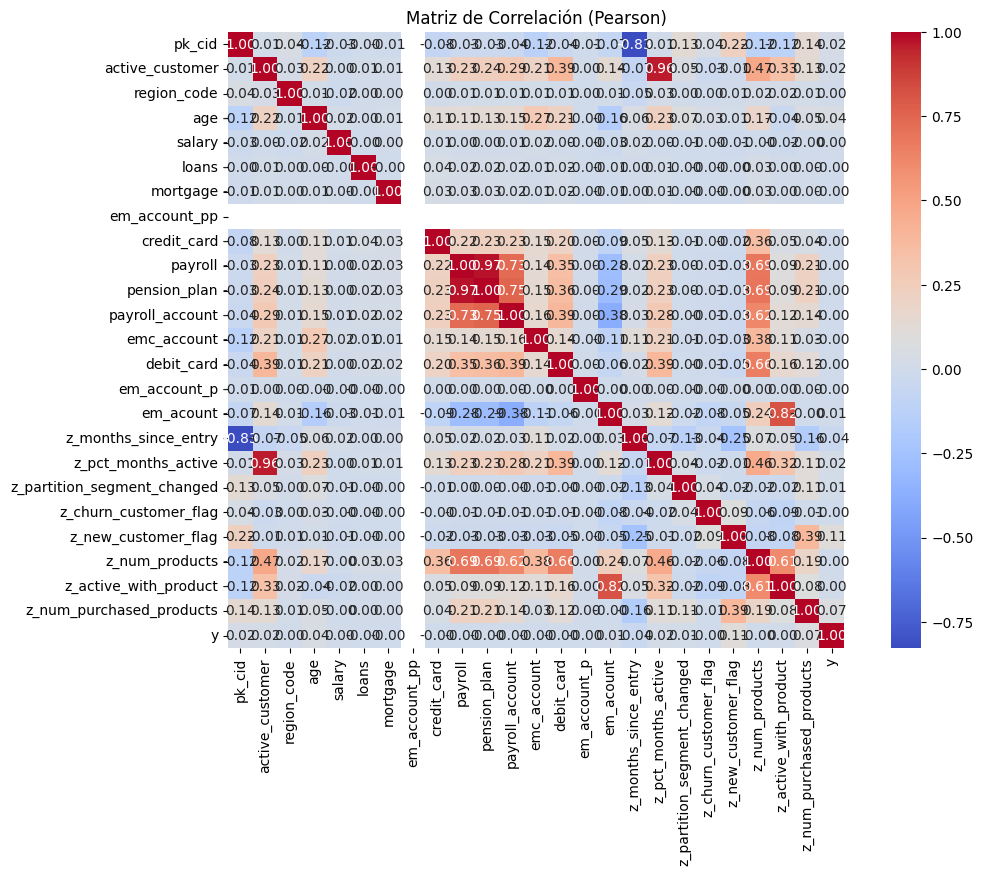

In [18]:
matriz_correlacion_numeric_features(df)

In [19]:
df.em_acount.value_counts(normalize=True)

em_acount
1   0.74
0   0.26
Name: proportion, dtype: float64

In [20]:
# Borramos "z_pct_months_active" por estar al 90% correlada con "active_customer" y "payroll_account" porque es igual que "payroll", borramos 'payroll' por altisima correlacion con pension plan
df.drop(columns=['z_pct_months_active', 'payroll_account', 'payroll', 'em_account_pp', 'em_account_p'], inplace=True)

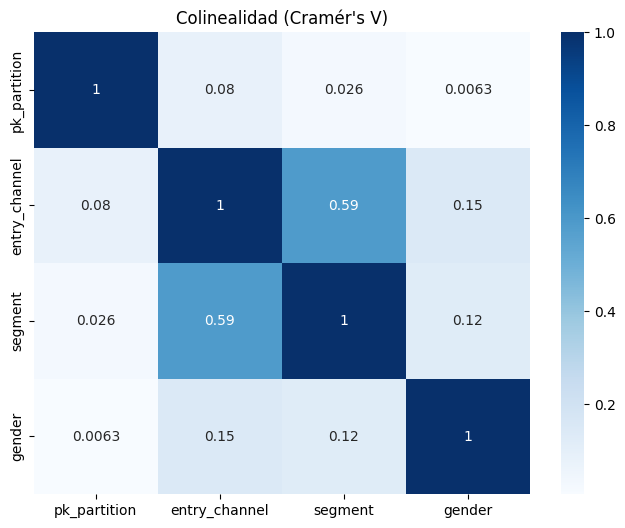

In [21]:
object_cols= df.select_dtypes(exclude=['number']).columns
matriz_correlacion_object_features(df, object_cols)

### 1.1 Fechas - estacionalidad 

In [22]:
df['pk_partition'] = pd.to_datetime(df['pk_partition'])

# Variables temporales
df['month'] = df['pk_partition'].dt.month
df['day_of_year'] = df['pk_partition'].dt.dayofyear
df['weekday'] = df['pk_partition'].dt.weekday  # 0 = lunes, 6 = domingo

# Transformación cíclica (reloj):
# Mes (12 meses)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
# Día del año (365 días)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
# Día de la semana (7 días)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

In [23]:
df.drop(columns={'month','day_of_year','weekday'}, inplace = True)

### 1.2 Encoding

In [24]:
df = group_minor_categories(df, 'entry_channel', 0.01)
df.drop(columns='entry_channel', inplace=True)

df.rename(columns={'entry_channel_grouped':'entry_channel'}, inplace=True)

In [25]:
# df = group_minor_categories(df, 'region_code', 0.005)
# df.drop(columns='region_code', inplace=True)

Mejor no agrupamos la región y le hacemos el Frequency Encoding que consideramos que nos va a aportar más información.

In [26]:
# Frequency Encoding:
freqenc_cols = ['region_code']
df = frequency_encode(df, freqenc_cols)

In [27]:
# One Hot Encoding:
ohe_cols = ['entry_channel','segment','gender']
df = one_hot_encode(df, ohe_cols)

### 1.3 Normalization

In [28]:
normalize_cols = ['age','salary','z_months_since_entry','z_num_products','z_num_purchased_products']

df = normalize_features(df, normalize_cols)

# 2. Modelling

In [29]:
# reordenamos dejando el target al final
col = df.pop("y")
df["y"] = col

In [30]:
print(df.shape)

(5785625, 42)


In [31]:
# localizamos la última partición:
max_partition = df.pk_partition.max()

# 1. la guardamos en otro df para la predicción final
df_last_partition = df[df["pk_partition"]==max_partition] 
# 2. borramos los registros de la última partición porque no sabemos lo que pasa al mes siguiente
df = df[df["pk_partition"]!=max_partition]
print(df.shape)

(5354190, 42)


In [32]:
df.head()

,pk_cid,pk_partition,active_customer,age,salary,loans,mortgage,credit_card,pension_plan,emc_account,debit_card,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,month_sin,month_cos,dayofyear_sin,dayofyear_cos,weekday_sin,weekday_cos,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V,y
0,1000028,2018-01-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.23,0,0,0,0.25,1,0.00,0.50,0.87,0.02,1.00,0.00,1.00,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
1,1000028,2018-02-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.25,0,0,0,0.25,1,0.00,0.87,0.50,0.52,0.85,0.43,-0.90,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
2,1000028,2018-03-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.26,0,0,0,0.25,1,0.00,1.00,0.00,0.86,0.51,0.43,-0.90,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
3,1000028,2018-04-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.28,0,0,0,0.25,1,0.00,0.87,-0.50,1.00,0.00,-0.78,0.62,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
4,1000028,2018-05-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.30,0,0,0,0.25,1,0.00,0.50,-0.87,0.87,-0.49,0.78,0.62,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00


In [33]:
df.y.value_counts()

y
0.00    5350260
1.00       3930
Name: count, dtype: int64

### 2.1 Undersampling

In [34]:
df_model = df.copy()

df_pos = df_model[df_model["y"] == 1]
df_neg = df_model[df_model["y"] == 0]

ratio = 3 
df_neg_sample = df_neg.sample(n=len(df_pos)*ratio, random_state=42)

df_balanced = pd.concat([df_pos, df_neg_sample], ignore_index=True).sample(frac=1, random_state=42)

X_bal = df_balanced.drop(columns=["y", "pk_cid", "pk_partition"])
y_bal = df_balanced["y"]

In [35]:
df_balanced.y.value_counts(normalize=True)

y
0.00   0.75
1.00   0.25
Name: proportion, dtype: float64

### 2.2 Model

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

model_us = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False
)

model_us.fit(X_train, y_train)

/Users/martadom/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:53:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### 2.3 Feature Importance

Hacemos este análisis para entender cuales son las variables que más poder tienen en la predicción.

In [37]:
importances = model_us.feature_importances_

In [38]:
feat_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feat_importances.sort_values(by='importance', ascending=False).head(20)

,feature,importance
13,z_new_customer_flag,0.30
10,z_months_since_entry,0.17
32,entry_channel_KHQ,0.08
26,entry_channel_KFC,0.07
36,segment_03 - UNIVERSITARIO,0.06
34,segment_01 - TOP,0.03
1,age,0.03
0,active_customer,0.02
12,z_churn_customer_flag,0.02
28,entry_channel_KHE,0.02


### 2.4 Evaluation

* Con el dataset balanceado:

In [39]:
y_pred_train = model_us.predict(X_train)
y_pred_test  = model_us.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("F1 score:", f1_score(y_test, y_pred_test))

Train accuracy: 0.9948314249363868
Test accuracy: 0.9570610687022901
F1 score: 0.9136276391554703


In [40]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

y_pred = model_us.predict(X_test)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

recall_positivos = tp / (tp + fn) * 100
accuracy_total = (tp + tn) / (tp + tn + fp + fn) * 100

# Prints (como los tenías)
print(f"Verdaderos positivos (1s acertados): {tp}")
print(f"Falsos negativos (1s perdidos): {fn}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 score: {f1}")
print(f"% de 1s acertados (recall): {recall_positivos:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total:.2f}%")

Verdaderos positivos (1s acertados): 714
Falsos negativos (1s perdidos): 72
Precision: 0.918918918918919
Recall: 0.9083969465648855
F1 score: 0.9136276391554703
% de 1s acertados (recall): 90.84%
% de aciertos total (accuracy): 95.71%


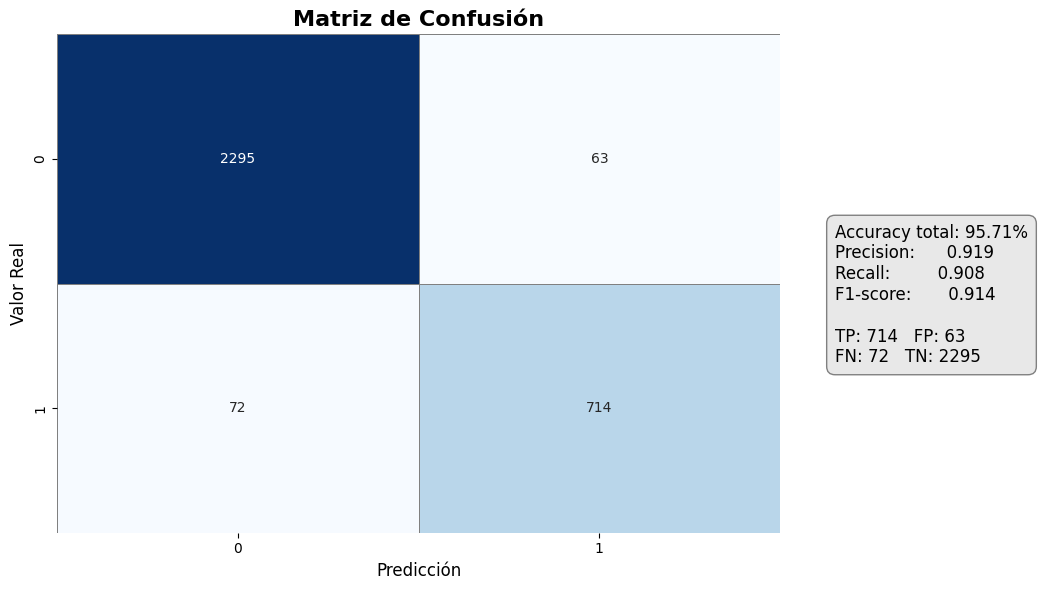

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text = (
    f"Accuracy total: {accuracy_total:.2f}%\n"
    f"Precision:      {precision:.3f}\n"
    f"Recall:         {recall:.3f}\n"
    f"F1-score:       {f1:.3f}\n\n"
    f"TP: {tp}   FP: {fp}\n"
    f"FN: {fn}   TN: {tn}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()

ROC AUC: 0.9908151989761453


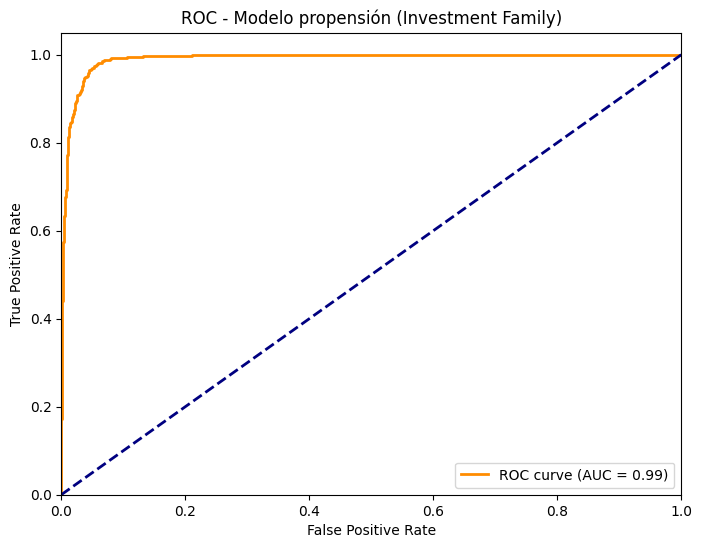

In [42]:
y_prob_test = model_us.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob_test))

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Investment Family)')
plt.legend(loc="lower right")
plt.show()

In [43]:
y_prob_test

array([1.3338686e-05, 1.7046080e-03, 2.4789495e-03, ..., 9.0923917e-01,
       2.9541876e-05, 6.8017252e-05], dtype=float32)

* Con el dataset total (sin balanceo):

In [44]:
X_full = df.drop(columns=["y", "pk_cid", "pk_partition"])
y_full = df["y"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

In [45]:
y_pred_train_full = model_us.predict(X_train_full)
y_pred_test_full  = model_us.predict(X_test_full)

print("Train accuracy:", accuracy_score(y_train_full, y_pred_train_full))
print("Test accuracy:", accuracy_score(y_test_full, y_pred_test_full))
print("F1 score:", f1_score(y_test_full, y_pred_test_full))

y_pred_full = y_pred_test_full 

tn_full, fp_full, fn_full, tp_full = confusion_matrix(y_test_full, y_pred_full).ravel()

precision_full = precision_score(y_test_full, y_pred_full)
recall_full = recall_score(y_test_full, y_pred_full)
f1_full = f1_score(y_test_full, y_pred_full)

recall_positivos_full = tp_full / (tp_full + fn_full) * 100
accuracy_total_full = (tp_full + tn_full) / (tp_full + tn_full + fp_full + fn_full) * 100

# Prints (igual que los tuyos)
print(f"Verdaderos positivos (1s acertados): {tp_full}")
print(f"Falsos negativos (1s perdidos): {fn_full}")
print(f"Precision: {precision_full}")
print(f"Recall: {recall_full}")
print(f"F1 score: {f1_full}")
print(f"% de 1s acertados (recall): {recall_positivos_full:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total_full:.2f}%")

Train accuracy: 0.9704595839893616
Test accuracy: 0.970156083366485
F1 score: 0.04563100997431763
Verdaderos positivos (1s acertados): 764
Falsos negativos (1s perdidos): 22
Precision: 0.023363914373088684
Recall: 0.9720101781170484
F1 score: 0.04563100997431763
% de 1s acertados (recall): 97.20%
% de aciertos total (accuracy): 97.02%


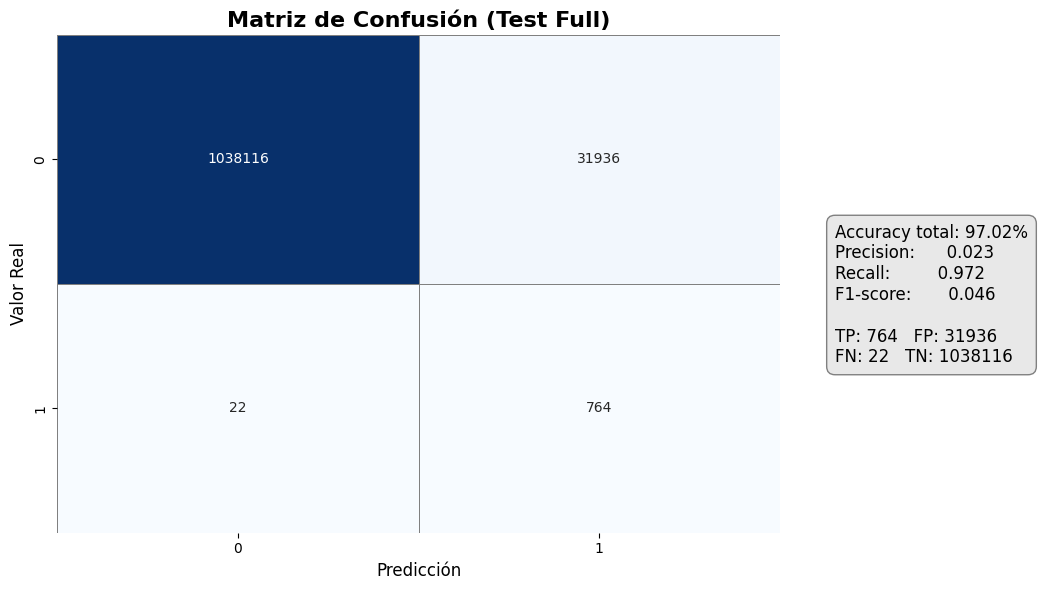

In [46]:
cm_full = confusion_matrix(y_test_full, y_pred_full)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_full,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión (Test Full)", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text_full = (
    f"Accuracy total: {accuracy_total_full:.2f}%\n"
    f"Precision:      {precision_full:.3f}\n"
    f"Recall:         {recall_full:.3f}\n"
    f"F1-score:       {f1_full:.3f}\n\n"
    f"TP: {tp_full}   FP: {fp_full}\n"
    f"FN: {fn_full}   TN: {tn_full}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text_full,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()

ROC AUC: 0.9939641443693269


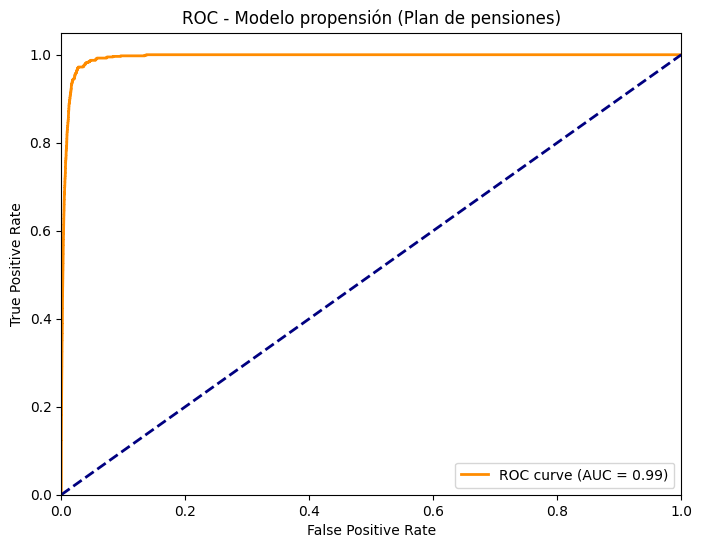

In [47]:
y_prob_test_full = model_us.predict_proba(X_test_full)[:,1]
print("ROC AUC:", roc_auc_score(y_test_full, y_prob_test_full))

fpr, tpr, thresholds = roc_curve(y_test_full, y_prob_test_full)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Plan de pensiones)')
plt.legend(loc="lower right")
plt.show()

# 3. Final Prediction

In [48]:
# Nos quedamos con los clientes vivos de la ultima partición para predecir
df_final = df_last_partition.merge(df_non_deceased_last_partition[['pk_cid']].drop_duplicates(), on ='pk_cid', how = 'inner')
df_final

,pk_cid,pk_partition,active_customer,age,salary,loans,mortgage,credit_card,pension_plan,emc_account,debit_card,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,month_sin,month_cos,dayofyear_sin,dayofyear_cos,weekday_sin,weekday_cos,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V,y
0,1000028,2019-05-01,1.00,0.41,0.00,0,0,0,0.00,0,1,1,0.53,0,0,0,0.25,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
1,1000096,2019-05-01,1.00,0.08,0.00,0,0,0,0.00,0,0,0,1.00,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
2,1000113,2019-05-01,0.00,0.50,0.00,0,0,0,0.00,0,0,0,0.94,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
3,1000130,2019-05-01,1.00,0.41,0.00,0,0,0,0.00,0,0,0,0.26,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
4,1000157,2019-05-01,1.00,0.41,0.00,0,0,0,0.00,0,0,1,0.74,0,0,0,0.12,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.06,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431359,998837,2019-05-01,1.00,0.34,0.00,0,0,0,0.00,0,0,1,0.23,0,0,0,0.12,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.05,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
431360,998859,2019-05-01,1.00,0.41,0.00,0,0,1,1.00,1,1,0,0.92,0,0,0,0.75,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
431361,999706,2019-05-01,0.00,0.12,0.00,0,0,0,0.00,0,0,0,0.09,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
431362,999825,2019-05-01,1.00,0.37,0.00,0,0,0,0.00,0,0,1,0.53,0,0,0,0.12,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.01,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00


In [49]:
print("Número de registros (last_partition): {}".format(df_final.pk_cid.count())) #434141
print("Número de ids únicos (last_partition): {}".format(df_final.pk_cid.nunique())) #434141
print("Número de particiones únicos (last_partition): {}".format(df_final.pk_partition.nunique())) #1

Número de registros (last_partition): 431364
Número de ids únicos (last_partition): 431364
Número de particiones únicos (last_partition): 1


In [50]:
X_last_partition = df_final.drop(columns=["y", "pk_cid", "pk_partition"])
y_prob_last_partition = model_us.predict_proba(X_last_partition)[:,1]

In [51]:
df_scored = df_final.copy()
df_scored["proba"] = y_prob_last_partition

In [52]:
df_scored[['pk_cid','proba']].sort_values(by='proba', ascending=False)

,pk_cid,proba
409950,1529549,1.00
430784,882865,1.00
122681,1164094,1.00
427876,256855,1.00
416465,1538581,1.00
...,...,...
264153,1342724,0.00
50356,1068587,0.00
163464,1211986,0.00
278067,1359099,0.00


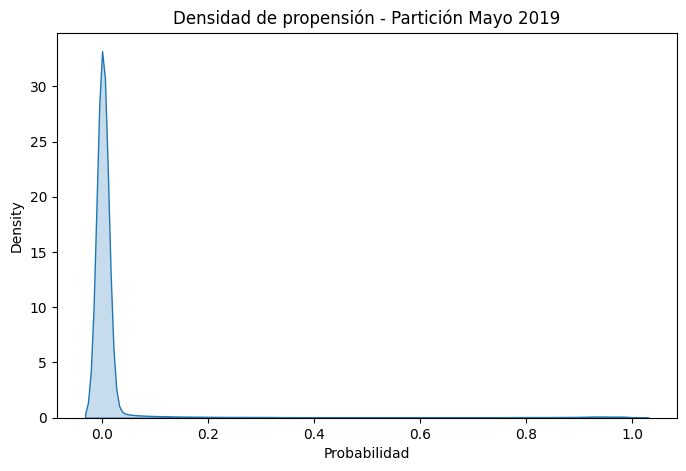

In [53]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.kdeplot(df_scored["proba"], fill=True)
plt.title("Densidad de propensión - Partición Mayo 2019")
plt.xlabel("Probabilidad")
plt.show()

In [54]:
# importamos el dataframe de products para ver quienes tienen algún producto de inversión
df_customer_products = pd.read_csv('../data/datasets_TFM + diccionario/customer_products.csv', sep=',')
df_customer_products.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_customer_products_last_partition = df_customer_products[df_customer_products["pk_partition"]==df_customer_products["pk_partition"].max()]

In [55]:
products = ['short_term_deposit', 'funds', 'securities', 'long_term_deposit']
df_customer_products_last_partition = df_customer_products_last_partition[['pk_cid']+products].drop_duplicates()
df_customer_products_last_partition['have_inversion_products'] = df_customer_products_last_partition[products].sum(axis=1)

In [56]:
df_customer_products_last_partition.have_inversion_products.value_counts()

have_inversion_products
0    434382
1      8026
2       552
3        35
Name: count, dtype: int64

Importante tener en cuenta:

- A 434382 clientes "se les va a poder vender" cualquier producto de inversión.
- 8026 clientes ya tienen uno, se le pueden vender 3.
- 552 ya tienen 2, se les puede vender 4
- 35 clientes ya tienen 3, se les puede todavía vender el último que les quede.

In [57]:
df_scored = df_scored.merge(df_customer_products_last_partition, on='pk_cid', how='left')

In [58]:
df_scored_final = df_scored.copy()

In [59]:
def assign_segment(proba):
    if proba >= 0.8:
        return "Top"
    elif proba >= 0.6:
        return "High"
    elif proba >= 0.4:
        return "Medium"
    else:
        return "Low"


df_scored_final["propensity_segment"] = df_scored_final["proba"].apply(assign_segment)
# df_scored_final = df_scored_final[["pk_cid", "proba", "propensity_segment"]].rename(columns={"proba": "propensity_score"})
df_scored_final = df_scored_final[["pk_cid",'short_term_deposit', 'funds', 'securities', 'long_term_deposit', 'have_inversion_products', "proba", "propensity_segment"]].rename(columns={"proba": "propensity_score"})


print(df_scored_final["propensity_segment"].value_counts())
print("-----------------------")
print(df_scored_final["propensity_segment"].value_counts(normalize=True))

propensity_segment
Low       416332
Top         7191
High        3993
Medium      3848
Name: count, dtype: int64
-----------------------
propensity_segment
Low      0.97
Top      0.02
High     0.01
Medium   0.01
Name: proportion, dtype: float64


In [63]:
df_scored_final.head()

,pk_cid,short_term_deposit,funds,securities,long_term_deposit,have_inversion_products,propensity_score,propensity_segment
0,1000028,0,0,0,0,0,0.00,Low
1,1000096,0,0,0,0,0,0.00,Low
2,1000113,0,0,0,0,0,0.00,Low
3,1000130,0,0,0,0,0,0.00,Low
4,1000157,0,0,0,0,0,0.00,Low


In [60]:
# Inversion Family
df_scored_final.groupby("propensity_segment")["propensity_score"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
propensity_segment,,,,,
High,3993,0.71,0.06,0.60,0.80
Low,416332,0.01,0.04,0.00,0.40
Medium,3848,0.50,0.06,0.40,0.60
Top,7191,0.91,0.06,0.80,1.00
